## Семинар: "Методы оптимизации"

In [1]:
from functools import partial

import numpy as np
import torch
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm
from matplotlib import animation
from mpl_toolkits import mplot3d
from matplotlib.gridspec import GridSpec
from torchvision import datasets, transforms
from IPython.display import HTML
%matplotlib inline
plt.rc('animation', html='html5')

/home/Applications/Data/programming/2025/data-portfolio/skils/NN_skils/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


На этом семинаре мы попробуем реализовать и сравнить различные методы оптимизации: SGD, Momentum, NAG, Adagrad, RMSProp, AdaDelta.

### Реализация методов

Для всех экспериментов подберите параметры так, чтобы метод сошелся к ближайшему локальному минимуму. Все методы следует запускать из одной и той же точки.

In [2]:
# https://github.com/dzlab/deepprojects/blob/master/visualization/Optimizers_in_Action.ipynb

def grid_samples(center=[0, 0], offset=5, size=100):
    range1 = np.linspace(center[0]-offset, center[0]+offset, size)
    range2 = np.linspace(center[1]-offset, center[1]+offset, size)
    return torch.from_numpy(np.stack(np.meshgrid(range1, range2))).float()


def mse(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1)


def msre(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1).sqrt()


def mae(y, y_hat):
    return ((y - y_hat).abs()).mean(axis=-1)


class LossAnimator:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.size = len(X)

    def loss_func(self, W, loss):
        shape = W.shape
        return loss((self.X @ W.view(shape[0], -1)).T, self.y).view(shape[1:])

    def plot_loss_funcs(self, weights, fcts, titles, view=(20, 50)):
        num_fcts = len(fcts)
        fig = plt.figure(figsize=(7 * num_fcts,7))
        for i in range(num_fcts):
            loss = self.loss_func(weights, loss=fcts[i])
            ax = fig.add_subplot(1, num_fcts, i+1, projection='3d')
            ax.plot_surface(*weights, loss, cmap='viridis')
            ax.set_xlabel('w0'); ax.set_ylabel('w1'); ax.set_zlabel('Loss')
            ax.set_title(titles[i])
            ax.view_init(*view)

    def _init_animation(self, epochs, train_data):
        self.train_data = train_data
        self.epochs = epochs
        self.nmethods = len(train_data)

        weights = grid_samples(offset=5)

        max_loss = max([data['losses'].max() for data in train_data.values()])
        loss_curve = self.loss_func(weights, loss=mse)
        colors = cm.rainbow(np.linspace(0, 1, self.nmethods))


        self.fig = plt.figure(figsize=(14, 8))
        self.gs = GridSpec(2, 2, width_ratios=[1, 2.5])

        self.ax0 = self.fig.add_subplot(self.gs[0,0])
        self.lines0 = {
            name: self.ax0.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax0.scatter(self.X[:,0], self.y, c='orange', label='Ground truth')
        self.ax0.set_ylim(self.y.min(), self.y.max())
        self.ax0.set_title('Ground truth & Model', fontsize=16)
        self.ax0.legend(loc='lower right')

        self.ax1 = self.fig.add_subplot(self.gs[:,1], projection='3d')
        self.ax1.plot_surface(*weights, loss_curve-0.5, cmap='viridis', alpha=0.8)
        self.ax1.view_init(50, 70)
        self.lines1 = {
            name: self.ax1.plot3D([], [], [], c=c, marker='o', alpha=0.9, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax1.set_title('Loss', fontsize=16, pad=20)
        self.ax1.set_xlabel('w0')
        self.ax1.set_ylabel('w1')
        self.ax1.set_zlabel('Loss')
        self.ax1.legend()

        self.ax2 = self.fig.add_subplot(self.gs[1,0])
        self.lines2 = {
            name: self.ax2.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax2.set_title('Loss', fontsize=16)
        self.ax2.set_ylabel('loss')
        self.ax2.set_ybound(0, max_loss)
        self.ax2.set_xlim(0, epochs)
        self.ax2.legend(loc='center right')

        self.fig.tight_layout()
        self.fig.subplots_adjust(top=0.85)

        plt.close()

        return self.fig

    def _animate(self, i):
        steps = np.arange(i+1)
        left = max(0, i-20)
        for name, data in self.train_data.items():
            # plot ground truth & model
            self.lines0[name].set_data(self.X[:, 0], self.X @ data['weights'][i])

            # plot loss (output of the sampling)
            self.lines1[name].set_data(data['weights'][left:i+1, 0], data['weights'][left:i+1, 1])
            self.lines1[name].set_3d_properties(data['losses'][left:i+1])

            self.lines2[name].set_data(steps, data['losses'][:i+1])

        self.fig.suptitle(f'Epoch: {i}/{self.epochs}', fontsize=22)

    def animate(self, epochs, train_data, step_skip=1):
        self._init_animation(epochs, train_data)
        anim = animation.FuncAnimation(self.fig, self._animate, frames=range(0, epochs, step_skip), interval=100 * step_skip)
        return HTML(anim.to_html5_video())

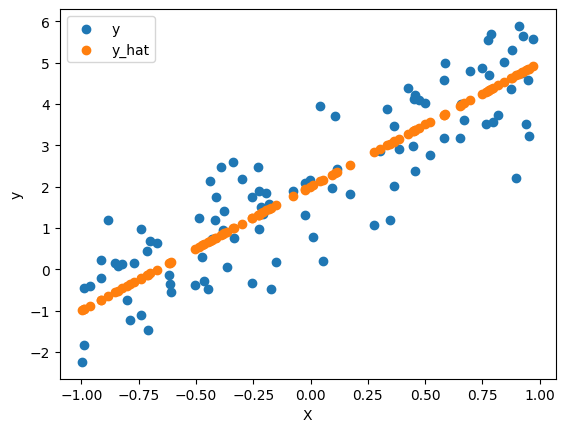

In [3]:
size = 100
X = torch.ones(size, 2)
X[:, 0].uniform_(-1., 1)

y_hat = 3 * X[:, 0] + 2
y = y_hat + torch.randn(size)

loss_animator = LossAnimator(X, y)

plt.scatter(loss_animator.X[:,0], loss_animator.y, label='y');
plt.scatter(loss_animator.X[:,0], y_hat, label='y_hat');
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

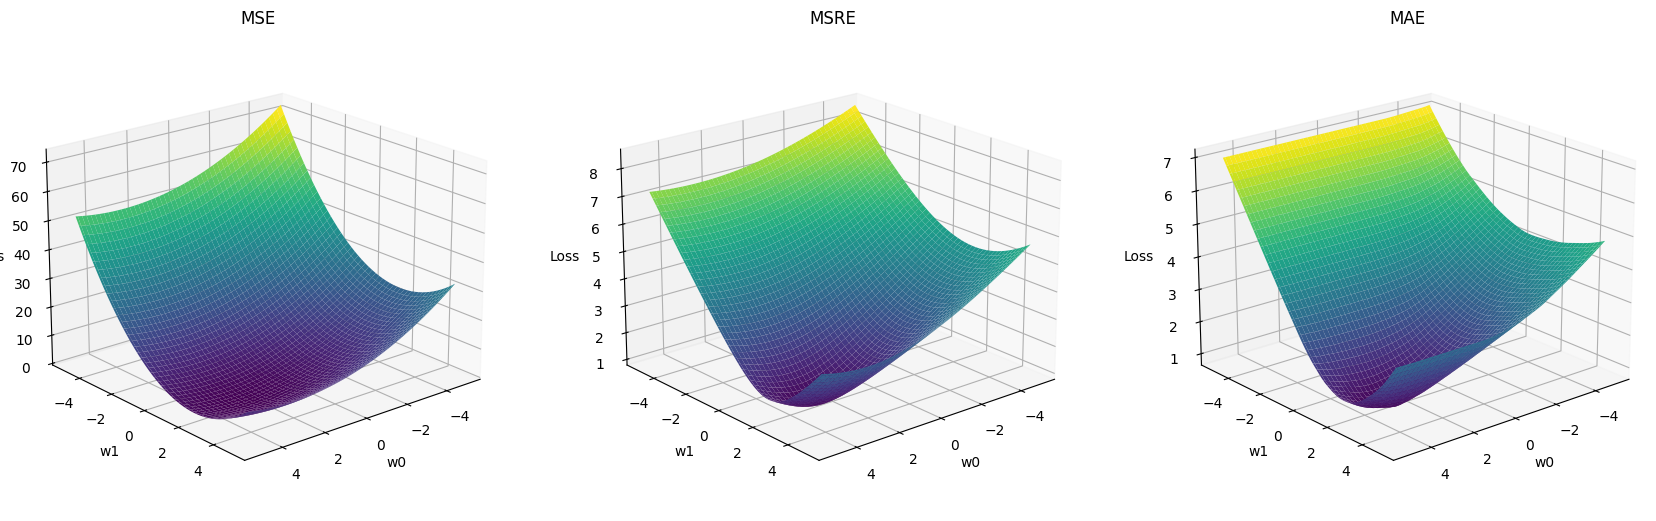

In [4]:
weights = grid_samples()
loss_animator.plot_loss_funcs(weights, [mse, msre, mae], ['MSE', 'MSRE', 'MAE'])

In [5]:
class Optimizer:
    def __init__(self, params):
        self.params = list(params)

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def pre_step(self):
        pass

    def step(self):
        pass

    def update_param(self, p):
        raise NotImplementedError()


In [6]:
def optimize_function(fn, optim, optim_args, start_point, num_iter = 50):
    weigths = nn.Parameter(torch.FloatTensor(start_point), requires_grad=True)

    optim = optim(params=[weigths], **optim_args)
    points = []
    losses = []
    for i in range(num_iter):
        if hasattr(optim, 'pre_step'):
            optim.pre_step()
        loss = fn(weigths)
        points.append(weigths.data.detach().clone())
        losses.append(loss.item())
        loss.backward()
        optim.step()
        optim.zero_grad()
    points = torch.stack(points, axis=0)
    losses = torch.FloatTensor(losses)
    return points, losses


In [7]:
def compare_optimizers(
    loss_animator,
    fn,
    optim_list,
    start_point,
    num_iter = 50,
    step_skip = 1
):
    data = {}
    loss_func = partial(loss_animator.loss_func, loss=fn)
    for name, optim, args in tqdm(optim_list):
        points, losses = optimize_function(loss_func, optim, args, start_point, num_iter)
        data[name] = {
            'weights': points,
            'losses': losses,
        }

    return loss_animator.animate(num_iter, data, step_skip=step_skip)

#### SGD
$$\theta_t = \theta_{t-1} - \eta \sum_{i_1, ..., i_k} \nabla_{\theta} J_{i} (\theta_{t-1})$$

In [8]:
class SGD(Optimizer):
    def __init__(self, params, lr=1e-2):
        super().__init__(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                p -= self.lr * p.grad


#### Momentum
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [9]:
class Momentum(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= self.prev_momentum[i]

#### Nesterov Accelerated Gradient (NAG)
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1} - \gamma \nu_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [10]:
class NAG(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= (1 + self.gamma) * self.prev_momentum[i] - self.gamma * prev_momentum

#### AdaGrad
$$G_t = \sum_{k=0}^t g_{k}^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [11]:
class AdaGrad(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2):
        super().__init__(params)
        self.epsilon = epsilon
        self.eta = eta

        self.G = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.G[i] += p.grad ** 2
                p -= self.eta * p.grad / torch.sqrt(self.G[i] + self.epsilon)

#### RMSProp
$$G_t = \gamma G_{t-1} + (1 - \gamma) g_t^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [12]:
class RMSProp(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2, gamma=0.9):
        super().__init__(params)
        self.eta = eta
        self.epsilon = epsilon
        self.gamma = gamma

        self.G = [torch.zeros(p.shape) for p in self.params]


    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                self.G[i] = self.gamma * self.G[i] + (1 - self.gamma) * (p.grad ** 2)
                p -= self.eta / torch.sqrt(self.G[i] + self.epsilon) * p.grad

In [13]:
from functools import partial

points, losses = optimize_function(
    partial(loss_animator.loss_func, loss=mse),
    SGD,
     {'lr': 1e-2},
    start_point=[-4, -4],
    num_iter=100
)

In [14]:
compare_optimizers(
    loss_animator,
    mae,
    [
        ['SGD', SGD, {'lr': 1e-1}],
        # ['Momentum', Momentum, {'lr': 1e-1}],
        # ['NAG', NAG, {'lr': 1e-1}],
        ['AdaGrad', AdaGrad, {'eta' : 1}],
        # ['RMSProp', RMSProp, {'eta' : 1}],
        ['Adam', Adam, {'lr' : 1e-1}],
        ['AdamW', AdamW, {'lr' : 1e-1}]
    ],
    start_point=[-4, -4],
    num_iter=100
)

NameError: name 'Adam' is not defined

###  Домашнее задание: Обучение нейронной сети + Подбор шага

В этом задании вам нужно:
1) Реализовать Adam, AdamW и обучить сверточную нейросеть на MNIST. Сравнить графики обучения для SGD, Adam и AdamW. **(2 балла)**
2) Реализовать LinearLR и CosineAnnealingLR. Обучить сверточную нейросеть на MNIST с SGD, Adam, AdamW с LinearLR, CosineAnnealingLR. Сравните графики изменения loss-функции и точности (суммарно должно быть 9 экспериментов, 3 из которых покрываются пунктом 1). **(3 балла)**

Ссылки:
- https://arxiv.org/abs/1711.05101 (AdamW, статья)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html (AdamW, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html (LinearLR, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html (CosineAnnealingLR, PyTorch)

In [ ]:
!wget www.di.ens.fr/~lelarge/MNIST.tar.gz
!tar -zxvf MNIST.tar.gz

--2025-09-26 15:46:53--  http://www.di.ens.fr/~lelarge/MNIST.tar.gz
Resolving www.di.ens.fr (www.di.ens.fr)... 129.199.99.14
Connecting to www.di.ens.fr (www.di.ens.fr)|129.199.99.14|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.di.ens.fr/~lelarge/MNIST.tar.gz [following]
--2025-09-26 15:46:54--  https://www.di.ens.fr/~lelarge/MNIST.tar.gz
Connecting to www.di.ens.fr (www.di.ens.fr)|129.199.99.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/x-gzip]
Saving to: ‘MNIST.tar.gz’

MNIST.tar.gz            [           <=>      ]  33.20M  2.76MB/s    in 17s     

2025-09-26 15:47:11 (1.99 MB/s) - ‘MNIST.tar.gz’ saved [34813078]

MNIST/
MNIST/raw/
MNIST/raw/train-labels-idx1-ubyte
MNIST/raw/t10k-labels-idx1-ubyte.gz
MNIST/raw/t10k-labels-idx1-ubyte
MNIST/raw/t10k-images-idx3-ubyte.gz
MNIST/raw/train-images-idx3-ubyte
MNIST/raw/train-labels-idx1-ubyte.gz
MNIST/raw/t10k-images-idx3-ubyte
MNIST/raw/tra

In [16]:
transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('.', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

In [30]:
class LRScheduler:
    def __init__(self, optimizer: Optimizer):
        self.optimizer = optimizer

    def step(self):
        pass

In [31]:
import math

In [46]:
class LinearLR(LRScheduler):
    def __init__(
        self,
        optimizer: Optimizer,
        start_factor: float = 0.1,
        end_factor: float = 1.0,
        total_iters: int = 100
    ):
        super().__init__(optimizer=optimizer)
        self.start_factor = start_factor
        self.end_factor = end_factor
        self.total_iters = total_iters
        
        self.initial_lr = self.optimizer.lr
        
    def step(self):
        if hasattr(self, "factor"):
            if self.factor < self.end_factor:
                self.factor += (self.end_factor - self.start_factor) / self.total_iters
                if self.factor > self.end_factor:
                    self.factor = self.end_factor
        else:
            self.factor = self.start_factor
        self.optimizer.lr = self.factor * self.initial_lr

class CosineAnnealing(LRScheduler):
    def __init__(
            self,
            optimizer: Optimizer,
            T_max: int = 20,
            eta_min: float = 0.01
        ):
        super().__init__(optimizer=optimizer)
        self.T_max = T_max
        self.eta_min = eta_min
        self.eta_max = optimizer.lr
        self.time_step = 0

    def step(self):
        self.time_step += 1
        eta_t = self.eta_min + 0.5 * (self.eta_max - self.eta_min) * \
                (1 + math.cos(math.pi * self.time_step / self.T_max))
        self.optimizer.lr = eta_t
        

$$
\begin{cases}
	m_t =\beta_1 m_{t-1} + (1 - \beta_1)g_t \\
	v_t = \beta_2 v_{t-1} + (1 - \beta_2)g_t^2
\end{cases}
$$

$$
	\theta_{t+1} = \theta_t -\frac{\eta}{\sqrt{\hat{v_t}} + e}\hat{m_t} 
$$

$$
	\begin{cases}
		\hat{m_t} = \frac{m_t}{1 - \beta_1^t} \\
		\hat{v_t} = \frac{v_t}{1 - \beta_2^t}
	\end{cases}
$$

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [48]:
class Adam(Optimizer):
    def __init__(self, params, lr=0.01, betas=(0.9, 0.999), eps=1e-8):
        params = list(params)
        super().__init__(params)
        self.lr = lr
        self.betas = betas
        self.eps = eps
        
        self.prev_m = [torch.zeros(p.shape, device=device) for p in params]
        self.prev_v = [torch.zeros(p.shape, device=device) for p in params]
        
        self.time_step = 0
        
    def step(self):
        self.time_step += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                
                prev_m = self.prev_m[i]
                prev_v = self.prev_v[i]
                self.prev_m[i] = self.betas[0] * prev_m + (1 - self.betas[0]) * p.grad
                self.prev_v[i] = self.betas[1] * prev_v + (1 - self.betas[1]) * (p.grad**2)
                
                m_hat = self.prev_m[i] / (1 - self.betas[0]**(self.time_step))
                v_hat = self.prev_v[i] / (1 - self.betas[1]**(self.time_step))
                
                p -= self.lr / (v_hat**0.5 + self.eps) * m_hat
                
        return        

In [49]:
class AdamW(Optimizer):
    def __init__(self, params, lr=0.01, betas=(0.9, 0.999), eps=1e-8, lambda_reg=0.001):
        params = list(params)
        super().__init__(params)
        self.lr = lr
        self.betas = betas
        self.eps = eps
        self.lambda_reg = lambda_reg
        
        self.prev_m = [torch.zeros(p.shape, device=device) for p in params]
        self.prev_v = [torch.zeros(p.shape, device=device) for p in params]
        
        self.time_step = 0
        
    def step(self):
        self.time_step += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                grads = p.grad
                g = grads # + self.lambda_reg * p
                prev_m = self.prev_m[i]
                self.prev_m[i] = self.betas[0] * prev_m + (1 - self.betas[0]) * g
                prev_v = self.prev_v[i]
                self.prev_v[i] = self.betas[1] * prev_v + (1 - self.betas[1]) * g**2
                
                m_hat = self.prev_m[i] / (1 - self.betas[0]**(self.time_step))
                v_hat = self.prev_v[i] / (1 - self.betas[1]**(self.time_step))
                
                p -= self.lr * (m_hat / (v_hat**0.5 + self.eps) + self.lambda_reg * p)
        return
            
            

In [50]:
import torch
import torch.nn as nn

class CustomCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.CNN_Module = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=4, stride=1, padding=0), # 28*28 -> 24*24
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=4), # 24*24 -> 6*6
            nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, padding=0, stride=1), # 6*6 -> 4*4
            nn.ReLU(),
            nn.Flatten()
        )
        
        self.fc1 = nn.Linear(in_features=64*4*4, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)
    
    def forward(self, x):
        x = self.CNN_Module(x)
        x = self.fc1(x)
        x = nn.functional.relu(x)
        x = self.fc2(x)
        return x

In [61]:
optimizers_list = [
    ["SGD", SGD, {"lr" : 1e-3}],
    ["Adam", Adam, {"lr" : 1e-3}],
    ["AdamW", AdamW, {"lr" : 1e-3}]
            ]

loss_params = {"train" : 
                    {   "SGD" : { "None" : [], "LinearLR" : [], "CosineAnnealing" : [] },
                        "Adam" : { "None" : [], "LinearLR" : [], "CosineAnnealing" : [] },
                        "AdamW" : { "None" : [], "LinearLR" : [], "CosineAnnealing" : [] }
                    },
                "test": 
                    {   "SGD" : { "None" : [], "LinearLR" : [], "CosineAnnealing" : [] },
                        "Adam" : { "None" : [], "LinearLR" : [], "CosineAnnealing" : [] },
                        "AdamW" : { "None" : [], "LinearLR" : [], "CosineAnnealing" : [] }
                    }
                }

shedulers_list = [
    [None, None, None],
    ["LinearLR", LinearLR, { "start_factor" : 0.1, "end_factor" : 1.0, "total_iters" : 10}],
    ["CosineAnnealing", CosineAnnealing, { "T_max" : 20, "eta_min" : 1e-4 }],
]

In [62]:
from typing import Optional

In [63]:
def train():
    for sheduler_idx in shedulers_list:
        for optimizer_idx in optimizers_list:
            model = CustomCNN()
            model = model.to(device=device)
            
            print(f"Optimizer: {optimizer_idx[0]}; Sheduler: {sheduler_idx[0]}")
            
            loss_fn = nn.CrossEntropyLoss()
            optimizer: Optimizer = optimizer_idx[1](model.parameters(), **optimizer_idx[2])
            if sheduler_idx[0] is None:
                sheduler: Optional[LRScheduler] = None
            else:
                sheduler: Optional[LRScheduler] = sheduler_idx[1](optimizer, **sheduler_idx[2])
            best_loss = np.inf
            best_model = None
            
            for epoch in tqdm(range(20)):
                running_loss = 0
                model.train()
                for i, data in enumerate(train_loader):
                    inputs, labels = data
                    inputs = inputs.to(device=device)
                    labels = labels.to(device=device)
                    
                    optimizer.zero_grad()
                    outputs = model(inputs)
                    loss = loss_fn(outputs, labels)
                    running_loss += loss.item()
                    loss.backward()
                    
                    optimizer.step()
                
                model.eval()
                
                running_vloss = 0
                
                with torch.no_grad():
                    for i, data in enumerate(test_loader):
                        inputs, labels = data
                        inputs = inputs.to(device=device)
                        labels = labels.to(device=device)
                        outputs = model(inputs)
                        loss = loss_fn(outputs, labels)
                        running_vloss += loss.item()
                
                if sheduler is not None:
                    sheduler.step()
                
                avg_train_loss = running_loss / len(train_loader)
                avg_val_loss   = running_vloss / len(test_loader)
                
                loss_params["train"][optimizer_idx[0]][str(sheduler_idx[0])].append(avg_train_loss)
                loss_params["test"][optimizer_idx[0]][str(sheduler_idx[0])].append(avg_val_loss)
                
                print(f"Epoch: {epoch}; avg_train_loss = {avg_train_loss}; avg_val_loss = {avg_val_loss}")
                
                if avg_val_loss < best_loss:
                    best_loss = avg_val_loss
                    best_model = model.state_dict()
            torch.save(best_model, f"models/{optimizer_idx[0]}-{sheduler_idx[0]}.pt")

In [64]:
train()

Optimizer: SGD; Sheduler: None


  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:13<04:16, 13.51s/it]

Epoch: 0; avg_train_loss = 1.8348262146631877; avg_val_loss = 0.9572356394685495


 10%|█         | 2/20 [00:26<04:01, 13.43s/it]

...

Epoch: 17; avg_train_loss = 2.928953294066024e-05; avg_val_loss = 0.04620333208144231


 95%|█████████▌| 19/20 [04:47<00:15, 15.13s/it]

Epoch: 18; avg_train_loss = 1.2618466379549175e-05; avg_val_loss = 0.048245210433124096


100%|██████████| 20/20 [05:02<00:00, 15.15s/it]

Epoch: 19; avg_train_loss = 8.253935193855e-06; avg_val_loss = 0.05015821418079502


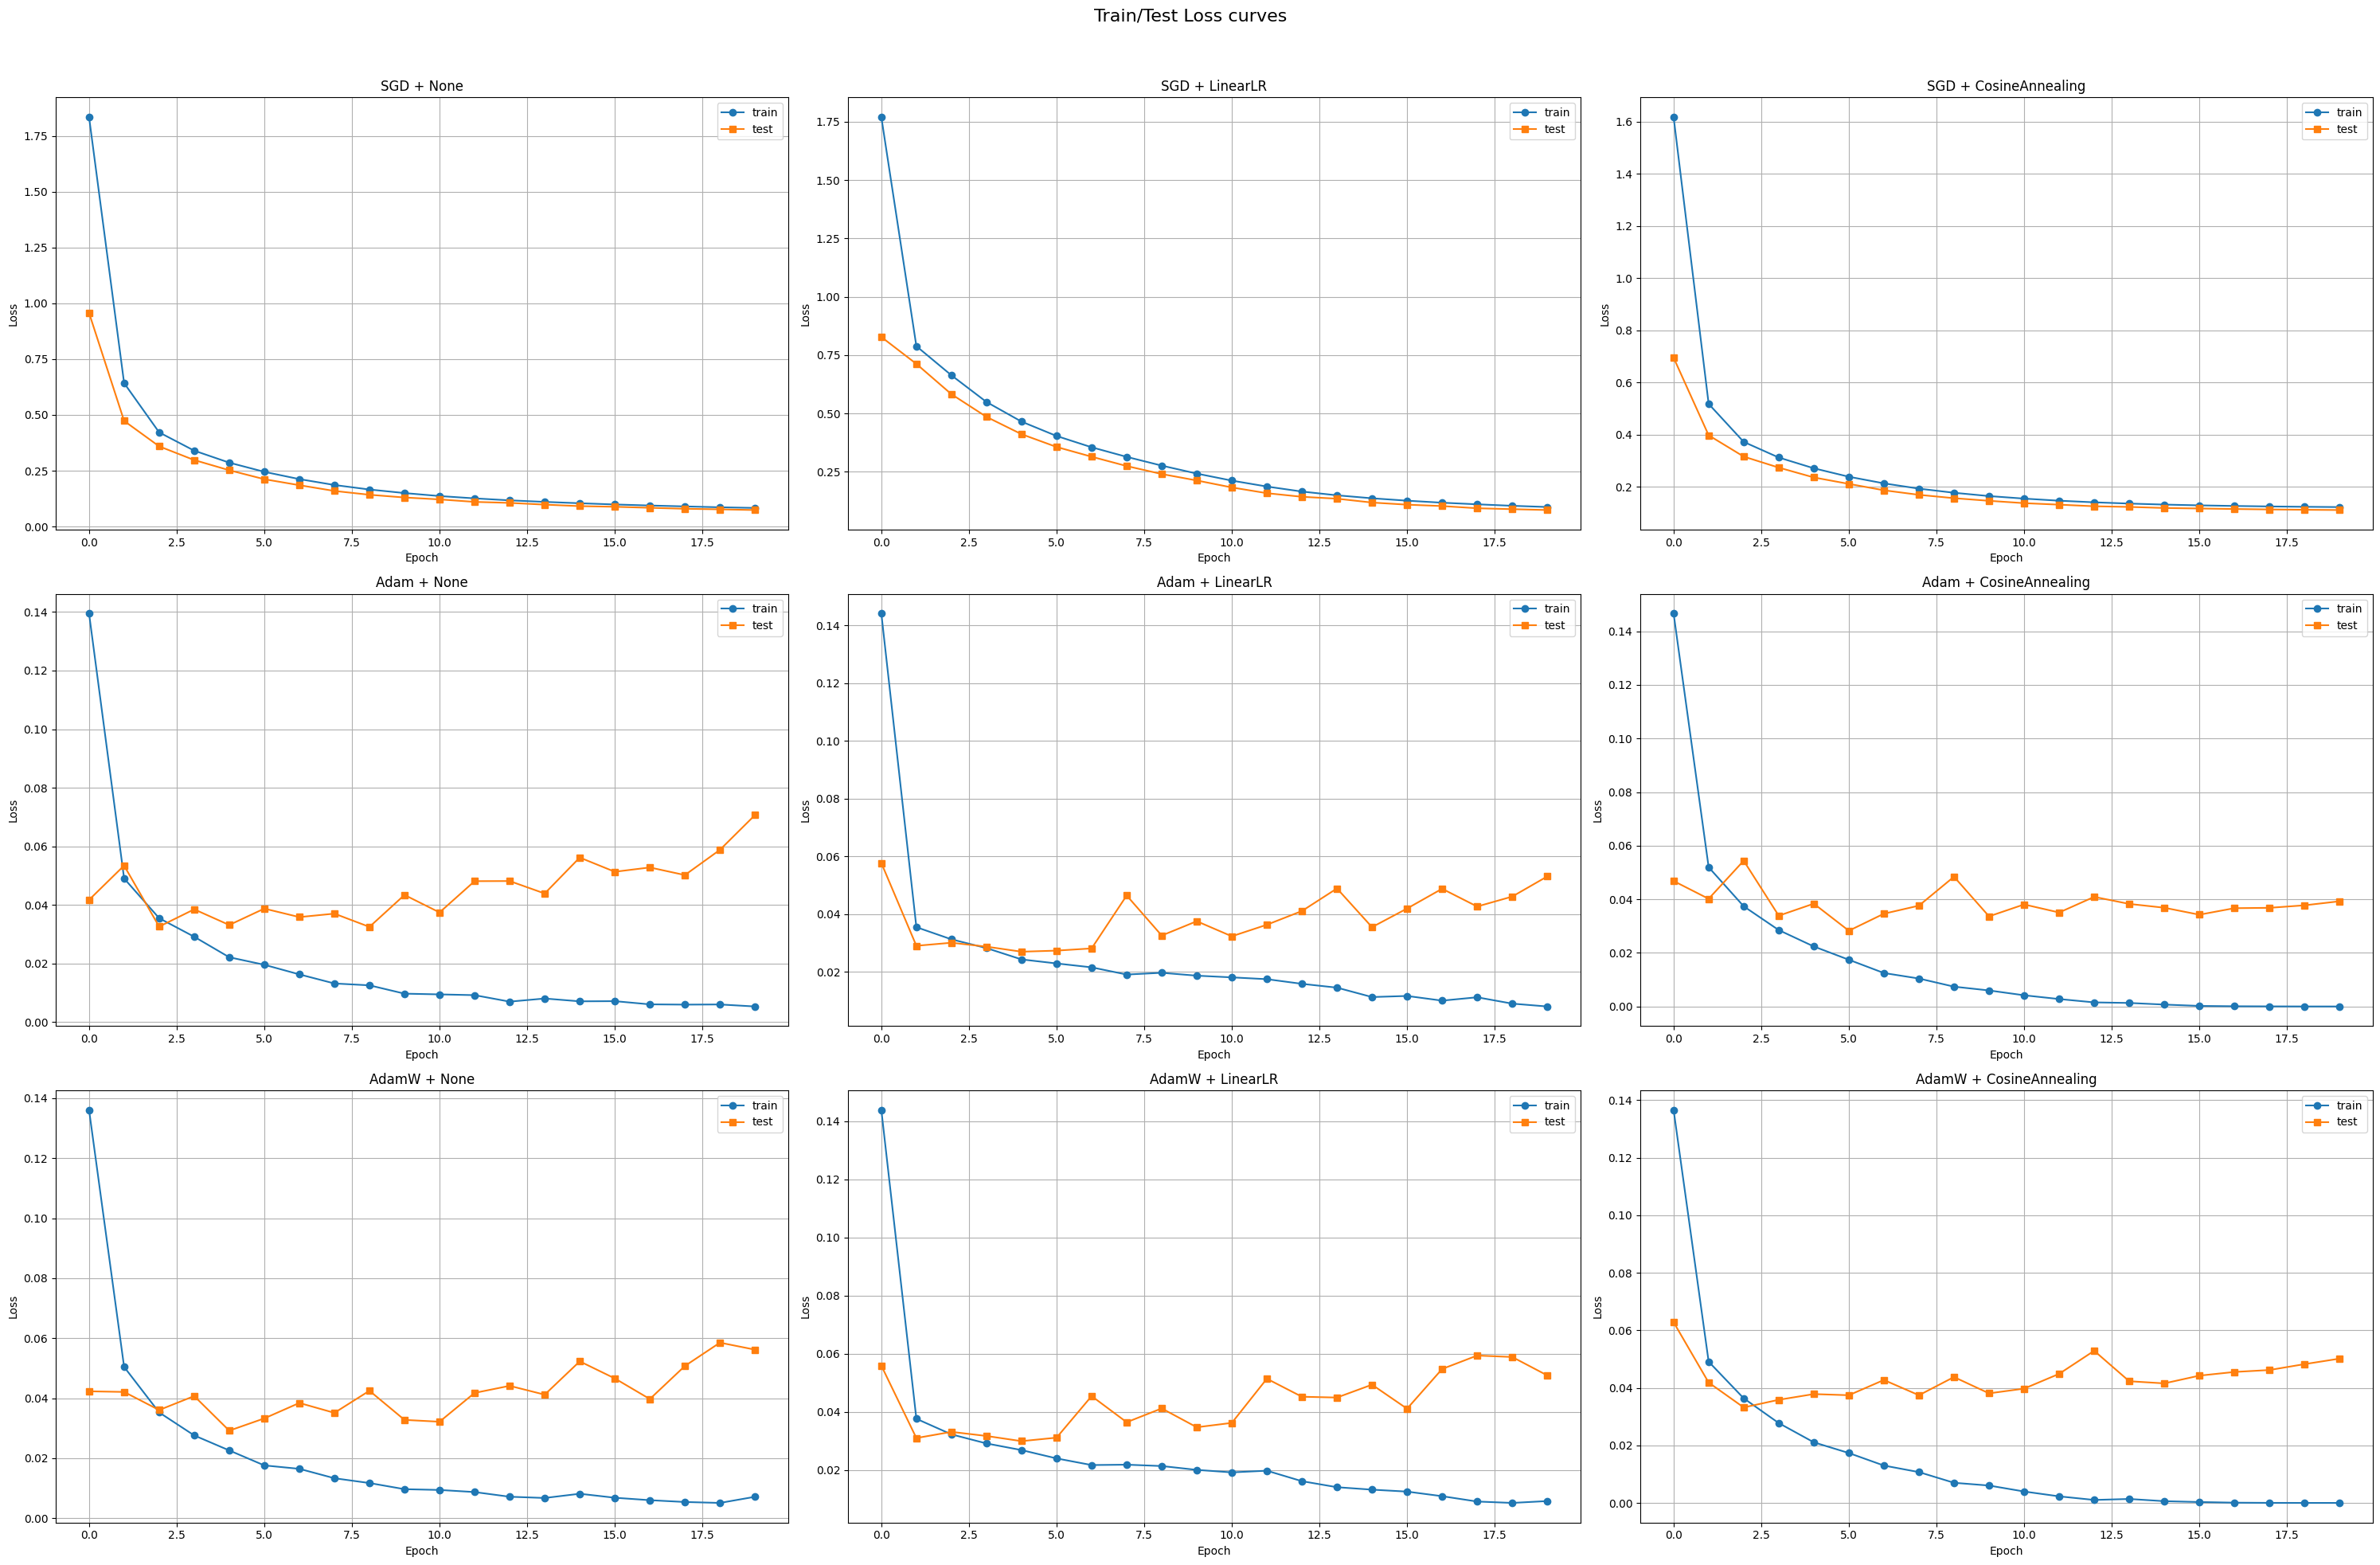

In [65]:
fig, axes = plt.subplots(3, 3, figsize=(30, 20))
fig.suptitle("Train/Test Loss curves", fontsize=16)

for i, opt in enumerate(optimizers_list):
    for j, sch in enumerate(shedulers_list):
        ax = axes[i, j]
        
        train_loss = loss_params["train"][str(opt[0])][str(sch[0])]
        test_loss = loss_params["test"][str(opt[0])][str(sch[0])]

        ax.plot(train_loss, label="train", marker="o")
        ax.plot(test_loss, label="test", marker="s")
        ax.set_title(f"{str(opt[0])} + {str(sch[0])}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.legend()
        ax.grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # чтобы заголовок не налезал
plt.show()

#### Feedback (опционально)

Здесь вы можете оставить список опечаток из лекции или семинара:

- Your text here

Здесь вы можете оставить комментарии по лекции или семинару:

- Your text here